### Importing required modules and libraries

In [21]:
# I/O & Visualization
import pandas as pd
import numpy as np
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
import itables

# Pre-processing 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Handle imbalance data
from imblearn.over_sampling import SMOTE

# Models
from sklearn.linear_model import LogisticRegression 
from sklearn.ensemble import RandomForestClassifier 
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Seaborn professional style
sns.set_style("whitegrid")

## 1. Data Ingestion

Converting from .csv to .parquet to compress the size & performance issues

In [ ]:
# Read in chunks to avoid OOM error
# df = pd.read_csv("D:/Datasets/airline_fraud_synthetic_dataset.csv", low_memory=False)

# Save as Parquet — snappy is fast to decompress, zstd is smaller
# df.to_parquet("airline_fraud_data.parquet", engine="pyarrow", compression="snappy", index=False)

Connecting to huggingface through GUI

**Note : Only run this one to autenticate the connection to huggingface**

In [ ]:
# from huggingface_hub import login
# login()

Creating a new public repo on huggingface & uploading the .parquet dataset

In [20]:
# from huggingface_hub import HfApi
# 
# api = HfApi()
# REPO_ID = "0xsquawk/airline_fraud_radar"
# 
# # Create a dataset repo (set private=True if needed)
# api.create_repo(repo_id=REPO_ID, repo_type="dataset", private=False, exist_ok=True)
# 
# # Upload the parquet file
# api.upload_file(
    # path_or_fileobj="D:/Datasets/airline_fraud_data.parquet",
    # path_in_repo="data/airline_fraud_data.parquet",
    # repo_id=REPO_ID,
    # repo_type="dataset"
# )

In [42]:
# Importing the parquet dataset
from huggingface_hub import HfFileSystem

fs = HfFileSystem()

with fs.open("datasets/0xsquawk/airline_fraud_radar/data/airline_fraud_data.parquet", "rb") as f:
    df_raw = pd.read_parquet(f, engine="pyarrow")

print(f"The shape of this dataset is: {df_raw.shape}")

The shape of this dataset is: (3000000, 20)


In [40]:
# Previewing the dataset
print(df_raw.head(10))

      transaction_date          payment_id           mrn     pnr  \
0  2025-01-01 00:00:46  02XCWOFKVZUYNKIYAT  02XCWOFKVZUY  02XCWO   
1  2025-01-01 00:00:48  FQ96IXUSPHNEQNQG29  FQ96IXUSPHNE  FQ96IX   
2  2025-01-01 00:00:48  M5J6WTJ8G5YGB3A7DE  M5J6WTJ8G5YG  M5J6WT   
3  2025-01-01 00:03:06  IRD5PU5Y7SOT0FUBOF  IRD5PU5Y7SOT  IRD5PU   
4  2025-01-01 00:03:24  KAFWWIC7IAIJH1VJZY  KAFWWIC7IAIJ  KAFWWI   
5  2025-01-01 00:03:39  8YHRT6TIGPEGCZZZWO  8YHRT6TIGPEG  8YHRT6   
6  2025-01-01 00:04:35  CR9R8H5IQPZFQS4D12  CR9R8H5IQPZF  CR9R8H   
7  2025-01-01 00:04:48  PQTLD31CGRC7SJJAZR  PQTLD31CGRC7  PQTLD3   
8  2025-01-01 00:05:11  OS640MLFA6AH75JVQL  OS640MLFA6AH  OS640M   
9  2025-01-01 00:05:17  N4UPN4V0N1H2Y8V9CL  N4UPN4V0N1H2  N4UPN4   

                       email_address       ip_address  \
0             iek8i70tqgf@icloud.com  205.153.250.110   
1  k0oaoqyjs8r@aeroline-partners.com  217.193.114.197   
2          hunfvk3z3x@protonmail.com   171.120.149.95   
3                   4bt

In [ ]:
# Checking data types
print(df_raw.info())

<class 'pandas.DataFrame'>
RangeIndex: 3000000 entries, 0 to 2999999
Data columns (total 20 columns):
 #   Column              Dtype  
---  ------              -----  
 0   transaction_date    str    
 1   payment_id          str    
 2   mrn                 str    
 3   pnr                 str    
 4   email_address       str    
 5   ip_address          str    
 6   device_id           str    
 7   route               str    
 8   amount              float64
 9   currency            str    
 10  card_type           str    
 11  card_bin            int64  
 12  card_last_4         int64  
 13  bank_name           str    
 14  bin_country         str    
 15  loyalty_tier        str    
 16  txn_origin_country  str    
 17  account_age_days    int64  
 18  failed_attempts     int64  
 19  is_fraud            int64  
dtypes: float64(1), int64(5), str(14)
memory usage: 895.5 MB
None


In [44]:
print(df_raw.describe().round(2))

           amount    card_bin  card_last_4  account_age_days  failed_attempts  \
count  3000000.00  3000000.00   3000000.00        3000000.00       3000000.00   
mean       269.22   473768.84      5001.31            408.70             0.27   
std        287.07    71374.62      2886.00            567.99             0.75   
min          1.00   305432.00         0.00              1.00             0.00   
25%        121.63   412345.00      2503.00             85.00             0.00   
50%        196.39   454678.00      5001.00            187.00             0.00   
75%        319.53   534567.00      7500.00            480.00             0.00   
max      26142.33   622202.00      9999.00           6500.00             5.00   

         is_fraud  
count  3000000.00  
mean         0.01  
std          0.12  
min          0.00  
25%          0.00  
50%          0.00  
75%          0.00  
max          1.00  


In [58]:
print(df_raw['card_last_4'].sort_values(ascending=False))

print((df_raw['card_last_4'] == 0).sum())
print((df_raw['card_last_4'] == 9999).sum())
print((df_raw['card_last_4'] == 8888).sum())
print((df_raw['card_last_4'] == 1111).sum())

811207     9999
723188     9999
1257213    9999
1590639    9999
1055661    9999
           ... 
2260198       0
1781167       0
2886601       0
2171117       0
1517085       0
Name: card_last_4, Length: 3000000, dtype: int64
298
295
308
270


In [ ]:
# Checking for NaN/Null values
print(df_raw.isna().sum())

transaction_date            0
payment_id                  0
mrn                         0
pnr                         0
email_address               0
ip_address                  0
device_id                   0
route                       0
amount                      0
currency                    0
card_type                   0
card_bin                    0
card_last_4                 0
bank_name                   0
bin_country                 0
loyalty_tier          2160872
txn_origin_country          0
account_age_days            0
failed_attempts             0
is_fraud                    0
dtype: int64


**Observations :**
1. The `transaction_date` data type is 'str' and needs to be corrected
2. The `card_last_4` column is missing the zeroes at the start of the sequence i.e., '375' should be '0375' and '56' should be '0056'


## Data Cleaning & Preprocessing

In [28]:
# Making a copy of the original raw dataset
df = df_raw.copy()

In [29]:
# Converting card_last_4 to dtype 'str' as we have 0 values at the start which otherwise wouldn't reflect if dtype is 'int'
df['card_last_4'] = df['card_last_4'].astype(str).str.zfill(4)

In [30]:
# Handling Missing Values in loyalty_tier column
df['loyalty_tier'] = df['loyalty_tier'].fillna('None')

In [8]:
# Converting the 'transaction_date' column data type to datetime
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

In [9]:
print(df.head(5))

           transaction_date          payment_id           mrn     pnr  \
0 2025-01-01 00:51:47+00:00  QFOL16BP3KK8P8MVW4  QFOL16BP3KK8  QFOL16   
1 2025-01-01 00:51:56+00:00  EQO1659JW6G2GPDQGZ  EQO1659JW6G2  EQO165   
2 2025-01-01 00:51:56+00:00  8QMG5KM6PWV02LAV2P  8QMG5KM6PWV0  8QMG5K   
3 2025-01-01 00:51:56+00:00  ZLZCONDGLRJCDISLJX  ZLZCONDGLRJC  ZLZCON   
4 2025-01-01 00:51:57+00:00  I7AFYHTH1Y3LFB8AXT  I7AFYHTH1Y3L  I7AFYH   

          email_address       ip_address                         device_id  \
0  nah0pjjt@outlook.com   160.175.72.140  208b73581f6f015c60aed4b21e9b568b   
1  upyg5qvvo@icloud.com    206.149.27.69  65d50b2ebed4b2b74be080d84bc12d5a   
2    7p3ohn3k@yahoo.com  128.134.164.181  790e410cc5480cd87810177d8e65e343   
3  ft93mtkf@outlook.com     163.185.42.2  411f9b7284ab3599666453bf81a094f1   
4      4svv43@yahoo.com   239.139.187.49  c05041dc0ae917c79a91c92aa9aac67b   

     route  amount currency   card_type  card_bin card_last_4  \
0  DEL-SIN   71.86      INR

## Exploratory Data Analysis

In [10]:
# Checking the ratio of fraud vs non-fraud distribution
df.is_fraud.value_counts(normalize=True)*100

is_fraud
0    98.7
1     1.3
Name: proportion, dtype: float64

The dataset has an overall fraud rate of 1.49%

In [11]:
# Define exchange rates relative to 1 USD (Updated exchange rates relative to 1 USD (June 2026))
exchange_rates = {
    'USD': 1.00,
    'GBP': 0.76,
    'EUR': 0.88,
    'INR': 94.67,
    'AED': 3.67,
    'SGD': 1.30,
    'AUD': 1.45,
    'CNY': 6.78,
    'QAR': 3.64,
    'CAD': 1.42,
    'JPY': 161.76,
    'BRL': 5.20,
    'ZAR': 16.61,
    'TRY': 46.49,
    'HKD': 7.80,
    'KRW': 1546.43
}

# Map exchange rates and calculate a standardized USD amount
# We divide the native amount by the currency's rate to normalize it to USD
df['fx_rate'] = df['currency'].map(exchange_rates)
df['amount_usd'] = df['amount'] / df['fx_rate']

Downsampling the data to avoid kernal crash as aggregating the 'amount' column is very resource intensive 

In [12]:
# Strategic Downsampling
# Taking a random sample of 50,000 rows to protect system memory or avoid kernal crash
df_sample = df.sample(n=50000, random_state=22)

# Plotting the cleaned, normalized distribution
plt.figure(figsize=(10,6))

sns.histplot(
    data=df_sample, 
    x='amount_usd',
    hue='is_fraud', 
    kde=True, 
    bins=50
)

plt.show()

ValueError: Cannot take a larger sample than population when 'replace=False'

### Calculating actual revenue loss after normalizing the currencies

In [ ]:
total_txn_amt = df['amount_usd'].sum()
print(f"Sum of total transaction amount in USD: {total_txn_amt:,.2f}")
fraud_total_amt = df.query("is_fraud == 1")['amount'].sum()
print(f"Sum of total fraud amount in USD: {fraud_total_amt:,.2f}")

fraud_perc_amt = fraud_total_amt * 100 / total_txn_amt
print(f"Percentage of revenue loss: {fraud_perc_amt:,.2f}%")

Sum of total transaction amount in USD: 578,806,359.97
Sum of total fraud amount in USD: 16,238,750.51
Percentage of revenue loss: 2.81%


### Categorical Risk Profiles

In [ ]:
# Aggregate the counts and sums
risk_profile = df.groupby(['card_type', 'bin_country', 'bank_name']).agg(
    total_transactions=('is_fraud', 'count'),    # Total number of rows
    fraud_transactions=('is_fraud', 'sum')       # Total number of 1s
).reset_index()

# Calculate the fraud rate manually
risk_profile['fraud_rate'] = (risk_profile['fraud_transactions'] / risk_profile['total_transactions']).round(3)

# Sort to find the most dangerous combinations at the top
risk_profile = risk_profile.sort_values(by='fraud_rate', ascending=False)

# Let's peek at the top 10 riskiest combinations
print(risk_profile.head(10))

      card_type bin_country            bank_name  total_transactions  \
2   Diners Club          US     Diners Club Intl               27792   
12        RuPay          IN  State Bank of India               83070   
18         Visa          IN           ICICI Bank              125630   
1          Amex          US     American Express              167237   
7    MasterCard          FR          BNP Paribas               97474   
6    MasterCard          DE        Deutsche Bank              111594   
3      Discover          US   Discover Financial               83236   
4    MasterCard          AE         Emirates NBD               55272   
20         Visa          SG             DBS Bank               69185   
22         Visa          US                Chase              389158   

    fraud_transactions  fraud_rate  
2                  446       0.016  
12                1311       0.016  
18                1962       0.016  
1                 2456       0.015  
7                 1501

In [ ]:
# Extracting the hour from date column
df['transaction_hour'] = df['transaction_date'].dt.hour

### Checking for fraud spikes during odd hours

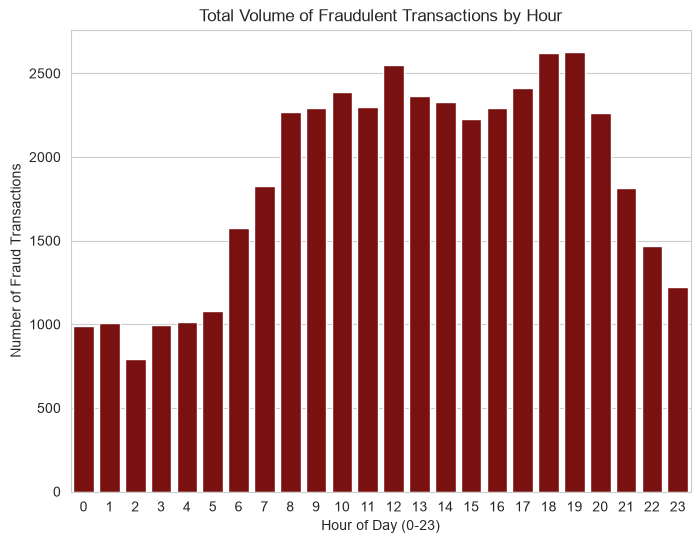

In [ ]:
plt.figure(figsize=(8,6))

fraud_txns = df[df['is_fraud'] == 1]

sns.countplot(
    x='transaction_hour',
    data=fraud_txns,
    color='darkred'
)

plt.title('Total Volume of Fraudulent Transactions by Hour')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Number of Fraud Transactions')
plt.show()

Observation: No unusual spikes are visible during odd or midnight hours

## Feature Engineering

In [ ]:
df_copy = df.copy()

In [ ]:
itables.show(df_copy)

Loading ITables v2.8.1 from the internet... (need help?)
